Introduction to Neural Networks

In [1]:
import numpy as np
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader, random_split

import seaborn as sns

# MNIST dataset

In [2]:
def load_mnist_dataset(mnist_path):
    x_trainval = get_images(Path(mnist_path)/Path('train-images-idx3-ubyte.gz'))
    y_trainval = get_labels(Path(mnist_path)/Path('train-labels-idx1-ubyte.gz'))

    x_train = x_trainval[:50000]
    y_train = y_trainval[:50000]

    x_val = x_trainval[50000:]
    y_val = y_trainval[50000:]

    x_test = get_images(Path(mnist_path)/Path('t10k-images-idx3-ubyte.gz'))
    y_test = get_labels(Path(mnist_path)/Path('t10k-labels-idx1-ubyte.gz'))

    return x_train, y_train, x_val, y_val, x_test, y_test

def get_labels(path):
    with gzip.open(path, 'rb') as data:
        labels = data.read()[8:]
        return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
    with gzip.open(path, 'rb') as data:
        _ = int.from_bytes(data.read(4), 'big')
        num_images = int.from_bytes(data.read(4), 'big')
        rows = int.from_bytes(data.read(4), 'big')
        cols = int.from_bytes(data.read(4), 'big')
        images = data.read()
        return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))

In [3]:
x_train, y_train, x_val, y_val, x_test, y_test = load_mnist_dataset('./data/mnist')

Establecemos los datos de prueba, validacion y entrenamiento. Tambien nos saltamos los 8 bytes de cabecera de los archivos "me imagino que es porque no los necesitamos"
Al final ajustamos el tamaño de las imagenes a 28x28, esto a las 60,000 imagenes.

In [4]:
x_train = x_train.copy().reshape(50000, -1).astype(np.float32)
y_train = y_train.copy().reshape(50000, 1)

x_val = x_val.copy().reshape(10000, -1).astype(np.float32)
y_val = y_val.copy().reshape(10000, 1)

x_test = x_test.copy().reshape(10000, -1).astype(np.float32)
y_test = y_test.copy().reshape(10000, 1)

Convertimos las imagenes a vectores de 784 pixeles a flotantes y las etiquetas a columnas tipo int

In [5]:
class MNISTDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y.squeeze(), dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

#Generamos datasets
train_dataset = MNISTDataset(x_train, y_train)  # 50,000
val_dataset   = MNISTDataset(x_val, y_val)       # 10,000
test_dataset  = MNISTDataset(x_test, y_test)     # 10,000

#Dividir en mini-batches automáticamente
#Mezclar los datos en cada época (shuffle)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)


Necesitas crear una clase que herede de Dataset, para poder utilizar pytorch    

In [6]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

# Defining the Neural Network

In [7]:
import torch.nn as nn
class NeuralNetwork(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 10)
        )

    def forward(self, x):
        return self.net(x)


No hace falta definir backward ni update, ya que PyTorch lo hace por nosotros.

Training the Neural Network

In [8]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss() # Función de pérdida para clasificación multiclase

Establecemos la función de perdida, la cual internamente aplica softmax + cross entropy.


In [9]:
from tqdm import tqdm

def train_model(model, optimizer, train_loader, val_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):

        model.train() 
        
        # tqdm crea la barra de progreso iterando sobre el train_loader
        epoch_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
        
        train_loss = 0.0
        
        for x_batch, y_batch in epoch_iterator:
            optimizer.zero_grad()               # 1. Limpiamos gradientes anteriores
            output = model(x_batch)             # 2. Pasamos los datos por la red (forward)
            loss = criterion(output, y_batch)   # 3. Calculamos qué tan mal lo hizo (loss)
            loss.backward()                     # 4. Calcula gradientes (backward)
            optimizer.step()                    # 5. El optimizador ajusta los pesos
            train_loss = loss.item()            # Guardamos el loss actual para mostrarlo
            epoch_iterator.set_postfix(train_loss=f"{train_loss:.4f}")
            
        model.eval()
        
        val_loss = 0.0
        correct = 0
        total = 0
        
        # torch.no_grad() apaga el cálculo de gradientes
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                output = model(x_batch)                      # 1. Obtenemos predicciones crudas
                loss = criterion(output, y_batch)            # 2. Calculamos el loss de validación
                
                val_loss += loss.item() * x_batch.size(0)    # Acumulamos el loss ponderado
                
                # Calculamos accuracy
                predictions = output.argmax(dim=1)           # Nos quedamos con la clase de mayor score
                correct += (predictions == y_batch).sum().item() # Contamos aciertos
                total += y_batch.size(0)                     # Contamos total de ejemplos
                
        # Calculamos promedios finales de validación
        val_loss = val_loss / total
        val_acc = correct / total
        
        print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}\n")
    return model



Definimos como es que vamos a realizar el entrenamiento. Se utiliza en funcion porque se llamara para cada modelo con diferentes valores de variables.

In [10]:
print("================ MODELO 1 ================")
# Arquitectura: 1 capa oculta de 200 neuronas
model1 = NeuralNetwork(hidden_size=200)

# Optimizador: Adam, LR: 0.001
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)

# Entrenamos por 10 épocas
model1 = train_model(model1, optimizer1, train_loader, val_loader, epochs=10)

================ MODELO 1 ================


Epoch 1/10: 100%|██████████| 196/196 [00:01<00:00, 138.13it/s, train_loss=0.1120]


Val Loss: 0.2536 | Val Accuracy: 0.9416



Epoch 2/10: 100%|██████████| 196/196 [00:01<00:00, 167.73it/s, train_loss=0.2184]


Val Loss: 0.1854 | Val Accuracy: 0.9540



...

Val Loss: 0.1583 | Val Accuracy: 0.9673



Epoch 9/10: 100%|██████████| 196/196 [00:01<00:00, 172.61it/s, train_loss=0.0087]


Val Loss: 0.1770 | Val Accuracy: 0.9664



Epoch 10/10: 100%|██████████| 196/196 [00:01<00:00, 185.62it/s, train_loss=0.0258]


Val Loss: 0.1590 | Val Accuracy: 0.9705



In [11]:
print("================ MODELO 2 ================")
# Arquitectura Cambiada: 1 capa de 50 neuronas 
model2 = NeuralNetwork(hidden_size=50)

# Optimizador Cambiado: SGD, LR Cambiado: 0.1
optimizer2 = optim.SGD(model2.parameters(), lr=0.1)

# Entrenamos por 10 épocas
model2 = train_model(model2, optimizer2, train_loader, val_loader, epochs=10)


================ MODELO 2 ================


Epoch 1/10: 100%|██████████| 196/196 [00:00<00:00, 221.95it/s, train_loss=2.3056]


Val Loss: 2.3019 | Val Accuracy: 0.1064



Epoch 2/10: 100%|██████████| 196/196 [00:00<00:00, 212.94it/s, train_loss=2.3100]


Val Loss: 2.3020 | Val Accuracy: 0.1064



...

Val Loss: 2.3021 | Val Accuracy: 0.1064



Epoch 9/10: 100%|██████████| 196/196 [00:00<00:00, 239.85it/s, train_loss=2.3047]


Val Loss: 2.3020 | Val Accuracy: 0.1064



Epoch 10/10: 100%|██████████| 196/196 [00:00<00:00, 244.24it/s, train_loss=2.2978]


Val Loss: 2.3021 | Val Accuracy: 0.1064



In [12]:
class NeuralNetworkM3(nn.Module):
    def __init__(self, hidden_size=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, hidden_size * 2),   # 784 → 512
            nn.ReLU(),
            nn.Linear(hidden_size * 2, hidden_size),      # 512 → 256
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),     # 256 → 128
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 10)               # 128 → 10
        )
 
    def forward(self, x):
        return self.net(x)

In [13]:
def train_model_early_stop(model, optimizer, train_loader, val_loader, epochs=50, patience=3, delta=0.005):
    criterion = nn.CrossEntropyLoss()
    val_losses = [] # Lista para almacenar el val_loss histórico

    for epoch in range(epochs):
        model.train() 
        epoch_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
        train_loss = 0.0
        
        for x_batch, y_batch in epoch_iterator:
            optimizer.zero_grad()               
            output = model(x_batch)             
            loss = criterion(output, y_batch)   
            loss.backward()                     
            optimizer.step()                    
            train_loss = loss.item()            
            epoch_iterator.set_postfix(train_loss=f"{train_loss:.4f}")
            
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                output = model(x_batch)                      
                loss = criterion(output, y_batch)            
                val_loss += loss.item() * x_batch.size(0)    
                predictions = output.argmax(dim=1)           
                correct += (predictions == y_batch).sum().item() 
                total += y_batch.size(0)                     
                
        val_loss = val_loss / total
        val_acc = correct / total
        
        print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}\n")
        
        # === INICIO DE LA LÓGICA DE EARLY STOPPING === #
        val_losses.append(val_loss) # Se guarda el loss de la época "n"
        n = epoch
        
        # Se evalúa solo si han pasado suficientes iteraciones (época n >= patience)
        if n >= patience:
            loss_n_minus_patience = val_losses[n - patience]
            loss_n = val_losses[n]
            
            # 1. Condición descrita en tu ejemplo (se detiene si avanzó muy poco):
            # abs(loss(n-patience) - loss(n)) < delta y loss(n-patience) >= loss(n)
            if abs(loss_n_minus_patience - loss_n) < delta and loss_n_minus_patience >= loss_n:
                print(f"Early stop activado en la época {n+1}: La mejora fue de solo {abs(loss_n_minus_patience - loss_n):.6f} (menor al delta establecido de {delta}).")
                break
                
            # 2. (Opcional pero ideal) Si la pérdida del modelo directamente empeoró en vez de mejorar
            elif loss_n > loss_n_minus_patience:
                print(f"Early stop activado en la época {n+1}: El rendimiento empeoró respecto a la iteración anterior.")
                break
            
    return model


Para el modelo 3 vamos a utilizar otra neuralnetwork y para entrenar vamos a utilizar early stop la implementacion sera manual.

In [14]:
print("================ MODELO 3 ================")
# Arquitectura Cambiada: 1 capa oculta de 50 neuronas 
model3 = NeuralNetwork(hidden_size=50)

# Optimizador Cambiado: SGD, LR Cambiado: 0.1 
optimizer3 = optim.SGD(model3.parameters(), lr=0.1)

# Entrenamos con la nueva función de early stop
model3 = train_model_early_stop(model3, optimizer3, train_loader, val_loader, epochs=50, patience=3, delta=0.005)


================ MODELO 3 ================


Epoch 1/50: 100%|██████████| 196/196 [00:00<00:00, 220.89it/s, train_loss=2.3074]


Val Loss: 2.3020 | Val Accuracy: 0.1064



Epoch 2/50: 100%|██████████| 196/196 [00:00<00:00, 276.35it/s, train_loss=2.3078]


Val Loss: 2.3017 | Val Accuracy: 0.1064



Epoch 3/50: 100%|██████████| 196/196 [00:01<00:00, 121.06it/s, train_loss=2.3026]


Val Loss: 2.3019 | Val Accuracy: 0.1064



Epoch 4/50: 100%|██████████| 196/196 [00:00<00:00, 215.55it/s, train_loss=2.2873]


Val Loss: 2.3021 | Val Accuracy: 0.1064

Early stop activado en la época 4: El rendimiento empeoró respecto a la iteración anterior.


Testing the model

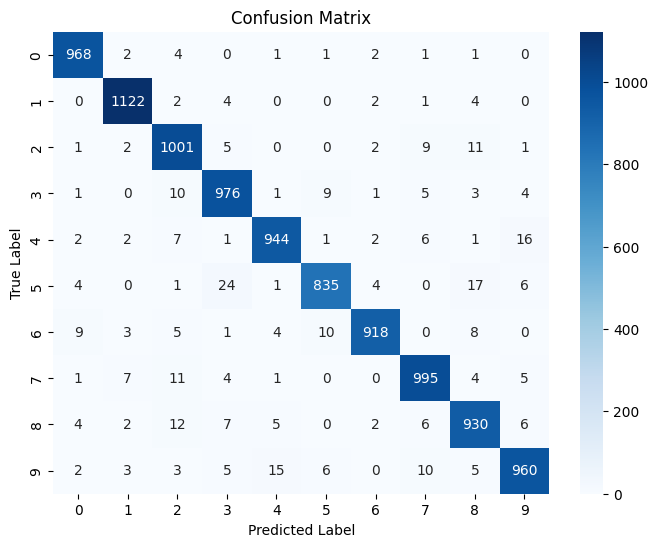

In [ ]:

# 1. Recolectar todas las predicciones y etiquetas reales procesando por batches
all_preds = []
all_labels = []

model1.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        output = model1(x_batch)
        predictions = output.argmax(dim=1)

        # .cpu().numpy() convierte los tensores de PyTorch de vuelta a arrays de NumPy
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# 2. Inicializar la matriz de confusión (10x10) en ceros
conf_matrix = np.zeros((10, 10), dtype=int)

# 3. Llenar la matriz contando las coincidencias
for true_label, pred_label in zip(all_labels, all_preds):
    conf_matrix[true_label, pred_label] += 1

# 4. Graficar el resultado con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


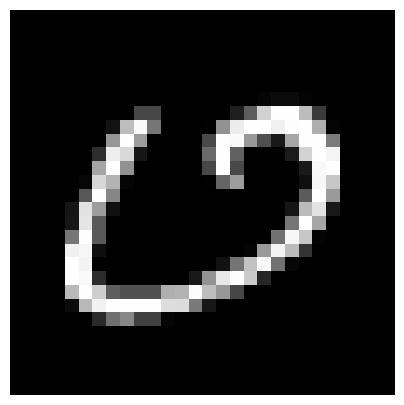

'Label: 0'

'Predicted: 1'

In [19]:
random_idx = np.random.randint(0, x_test.shape[0])
plot_number(x_test[random_idx])
display(f"Label: {y_test[random_idx].squeeze()}", f"Predicted: {all_preds[random_idx]}")

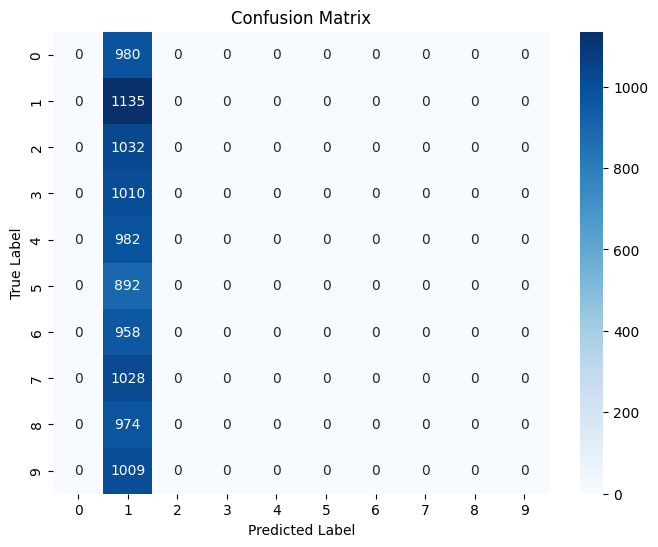

In [20]:

# 1. Recolectar todas las predicciones y etiquetas reales procesando por batches
all_preds = []
all_labels = []

model2.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        output = model2(x_batch)
        predictions = output.argmax(dim=1)
        
        # .cpu().numpy() convierte los tensores de PyTorch de vuelta a arrays de NumPy
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# 2. Inicializar la matriz de confusión (10x10) en ceros
conf_matrix = np.zeros((10, 10), dtype=int)

# 3. Llenar la matriz contando las coincidencias
for true_label, pred_label in zip(all_labels, all_preds):
    conf_matrix[true_label, pred_label] += 1

# 4. Graficar el resultado con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[str(i) for i in range(10)], 
            yticklabels=[str(i) for i in range(10)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


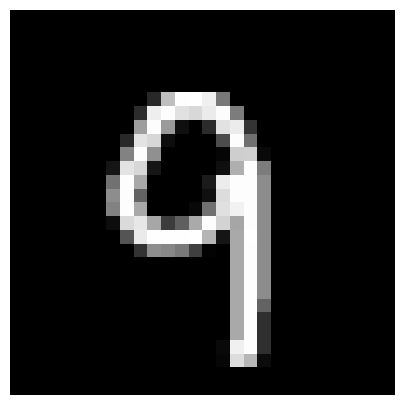

'Label: 9'

'Predicted: 1'

In [21]:
random_idx = np.random.randint(0, x_test.shape[0])
plot_number(x_test[random_idx])
display(f"Label: {y_test[random_idx].squeeze()}", f"Predicted: {all_preds[random_idx]}")

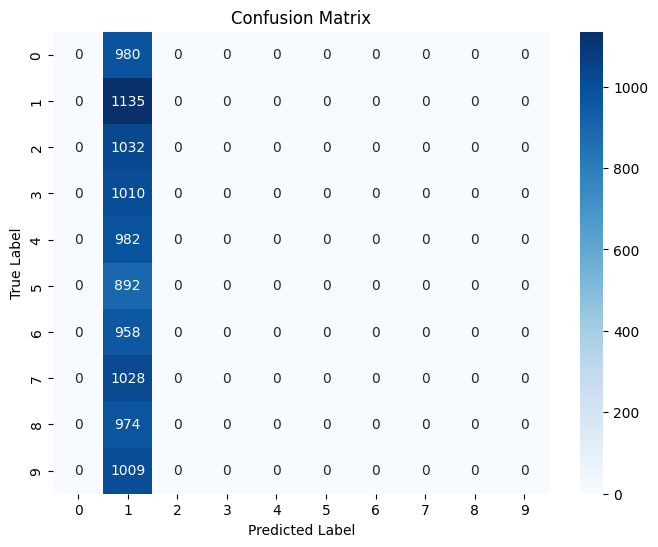

In [22]:

# 1. Recolectar todas las predicciones y etiquetas reales procesando por batches
all_preds = []
all_labels = []

model3.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        output = model3(x_batch)
        predictions = output.argmax(dim=1)
        
        # .cpu().numpy() convierte los tensores de PyTorch de vuelta a arrays de NumPy
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# 2. Inicializar la matriz de confusión (10x10) en ceros
conf_matrix = np.zeros((10, 10), dtype=int)

# 3. Llenar la matriz contando las coincidencias
for true_label, pred_label in zip(all_labels, all_preds):
    conf_matrix[true_label, pred_label] += 1

# 4. Graficar el resultado con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[str(i) for i in range(10)], 
            yticklabels=[str(i) for i in range(10)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


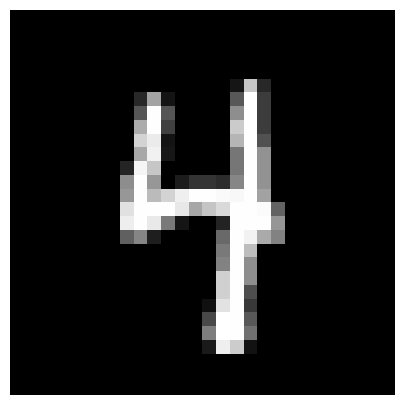

'Label: 4'

'Predicted: 1'

In [23]:
random_idx = np.random.randint(0, x_test.shape[0])
plot_number(x_test[random_idx])
display(f"Label: {y_test[random_idx].squeeze()}", f"Predicted: {all_preds[random_idx]}")